In [1]:
from COSMOtherm.funcs import load_and_sort_solvents, get_training_data, list_files_with_extension
from COSMOtherm.Configfiles import Config

init_files = list_files_with_extension(Config.initialSamples_dir, 'tab')
BO_files = list_files_with_extension(Config.outputfile_dir, 'tab')
solvents = load_and_sort_solvents(Config.solvents_fullpath)

train_X_init, train_Y_init, = get_training_data(init_files, solvents=solvents)
train_X, train_Y = get_training_data(BO_files, solvents=solvents) 

In [2]:
import torch
import botorch
import gpytorch
from botorch.fit import fit_gpytorch_mll
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize

train_X_all = torch.cat([train_X_init, train_X], dim=0)
train_Y_all = torch.cat([train_Y_init, train_Y], dim=0)


model = botorch.models.SingleTaskGP(
    train_X=train_X_all, 
    train_Y=train_Y_all,
    input_transform=Normalize(d=train_X_all.shape[1]),
    outcome_transform=Standardize(m=train_Y_all.shape[1]),
    )
mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll=mll)

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): RBFKernel(
      (lengthscale_prior): LogNormalPrior()
      (raw_lengthscale_constraint): GreaterThan(2.500E-02)
    )
    (outcome_transform): Standardize()
    (input_transform): Normalize()
  )
)

In [6]:
import torch


tC_range = [20, 40]  # [°C]
solvents_range = [0, 42]
test_tc = torch.linspace(tC_range[0], tC_range[1], 100).unsqueeze(1)  # Temperature
test_solvents = torch.linspace(solvents_range[0], solvents_range[1], 100).unsqueeze(1)  # Solvent index



max_x1_lacticacid = train_X_all[:,1].max().item()  # Set the fixed mole fraction value
min_x1_lacticacid = train_X_all[:,1].min().item()  # Set the fixed mole fraction value

test_tc, test_solvents = torch.meshgrid(test_tc.squeeze(), test_solvents.squeeze(), indexing='ij')
test_max_x1_lacticacid = torch.full_like(test_tc, max_x1_lacticacid)
test_min_x1_lacticacid = torch.full_like(test_tc, min_x1_lacticacid)

test_X_max = torch.stack([test_tc, test_max_x1_lacticacid, test_solvents], dim=-1).reshape(-1, 3)
test_X_min = torch.stack([test_tc, test_min_x1_lacticacid, test_solvents], dim=-1).reshape(-1, 3)

plot_tc =train_X_all[:, 0].numpy()
plot_solvents = train_X_all[:, 2].numpy()


In [7]:
model.eval()
means = []
with torch.no_grad():
        posterior = model.posterior(test_X_max)
        mean = posterior.mean.squeeze(-1).numpy()
        lower, upper = posterior.mvn.confidence_region()
        lower = lower.numpy()
        upper = upper.numpy()
mean = mean.reshape(100, 100)
lower = lower.reshape(100, 100)
upper = upper.reshape(100, 100)
means.append(mean)

with torch.no_grad():
        posterior = model.posterior(test_X_min)
        mean = posterior.mean.squeeze(-1).numpy()
        lower, upper = posterior.mvn.confidence_region()
        lower = lower.numpy()
        upper = upper.numpy()
mean = mean.reshape(100, 100)
lower = lower.reshape(100, 100)
upper = upper.reshape(100, 100)
means.append(mean)

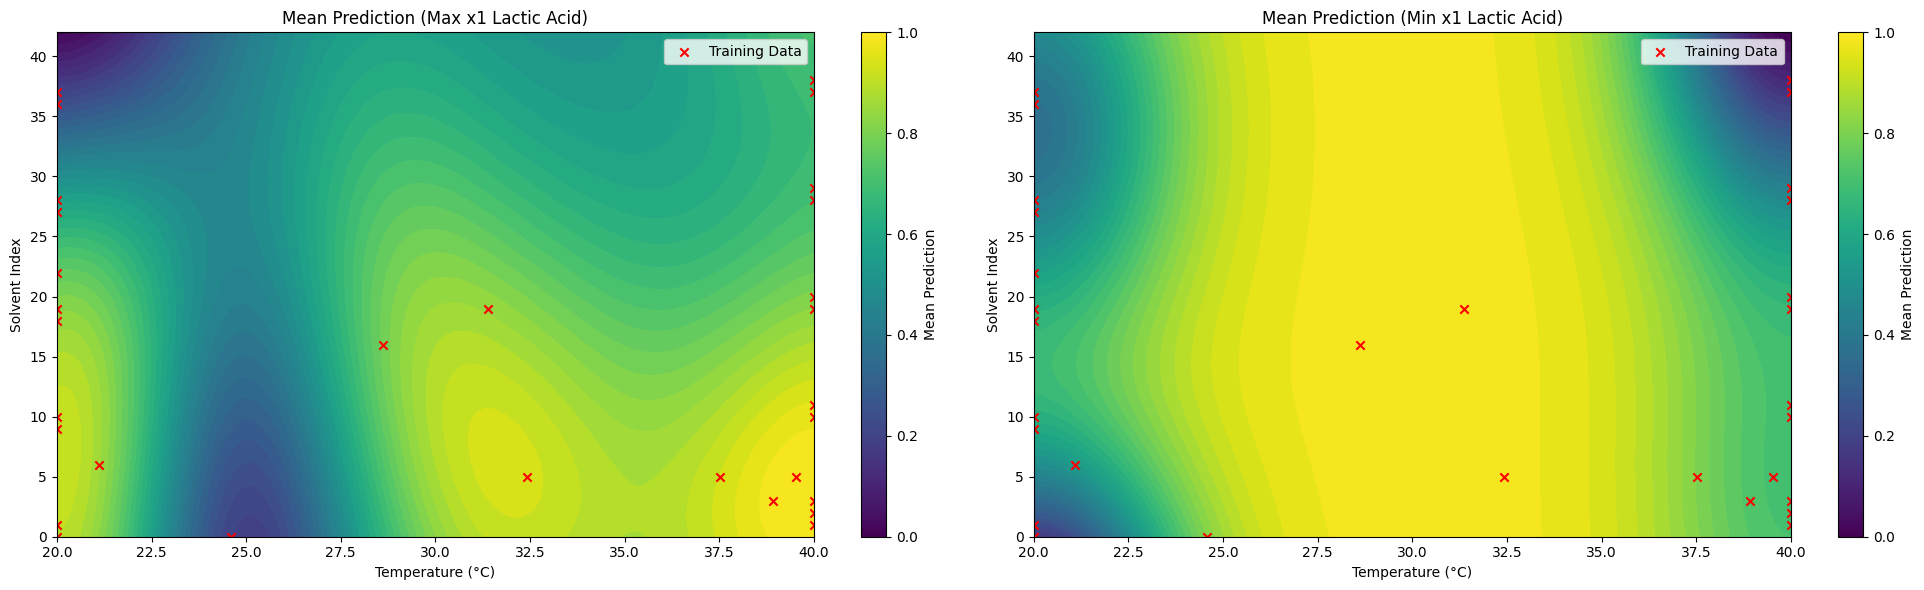

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot for means[0]
axes[0].contourf(test_tc, test_solvents, means[0], levels=50, cmap='viridis')
axes[0].set_title('Mean Prediction (Max x1 Lactic Acid)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Solvent Index')
axes[0].scatter(plot_tc, plot_solvents, c='red', marker='x', label='Training Data')
axes[0].legend()
axes[0].colorbar = plt.colorbar(axes[0].collections[-1], ax=axes[0], label='Mean Prediction')

# Plot for means[1]
axes[1].contourf(test_tc, test_solvents, means[1], levels=50, cmap='viridis')
axes[1].set_title('Mean Prediction (Min x1 Lactic Acid)')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Solvent Index')
axes[1].scatter(plot_tc, plot_solvents, c='red', marker='x', label='Training Data')
axes[1].legend()
axes[1].colorbar = plt.colorbar(axes[1].collections[-1], ax=axes[1], label='Mean Prediction')

plt.tight_layout()

In [30]:
max_count = (train_X_all[-10:, 1] == train_X_all.max(dim=0).values[1]).sum()
print(max_count)
min_count = (train_X_all[-10:, 1] == train_X_all.min(dim=0).values[1]).sum()
print(min_count)

tensor(6)
tensor(0)


tensor(0)